## All the imports
import data set and all libraries that will be used later


In [55]:
import pandas as pd

from matplotlib import pyplot as plt 
%matplotlib inline

import seaborn as sb

from sklearn.preprocessing import StandardScaler

from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

# models
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# path to the file to read
pcos_file_path = 'data\data without infertility _final.csv'

pcos_data = pd.read_csv(pcos_file_path) 

## Data info
seeing some statistics about the data

In [ ]:
pcos_data.info()

In [56]:
pcos_data.columns = pcos_data.columns.str.strip()
# to remove uneceserry spaces

In [ ]:
pcos_data.info()

<Axes: >

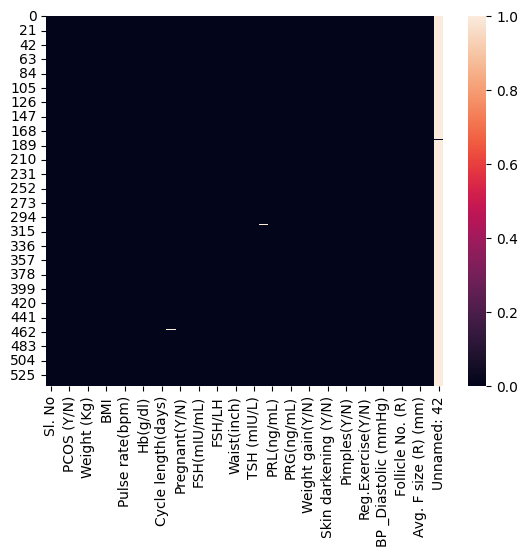

In [57]:
#to see empty data ; in our case it is col 42
sb.heatmap(pcos_data.isnull())

## Cleaning data
We have to remove null values and all values should be numerical

In [58]:
#dropping col that has all null values, and then id cols cause they are not needed for the clasification
#axis=1 is for col axis=0 is for rows
pcos_data.drop(["Unnamed: 42", "Sl. No", "Patient File No."], axis=1, inplace=True)

In [ ]:
sb.heatmap(pcos_data.isnull())

In [59]:
pcos_data.isnull().sum()

PCOS (Y/N)               0
Age (yrs)                0
Weight (Kg)              0
Height(Cm)               0
BMI                      0
Blood Group              0
Pulse rate(bpm)          0
RR (breaths/min)         0
Hb(g/dl)                 0
Cycle(R/I)               0
Cycle length(days)       0
Marraige Status (Yrs)    1
Pregnant(Y/N)            0
No. of aborptions        0
FSH(mIU/mL)              0
LH(mIU/mL)               0
FSH/LH                   0
Hip(inch)                0
Waist(inch)              0
Waist:Hip Ratio          0
TSH (mIU/L)              0
AMH(ng/mL)               1
PRL(ng/mL)               0
Vit D3 (ng/mL)           0
PRG(ng/mL)               0
RBS(mg/dl)               0
Weight gain(Y/N)         0
hair growth(Y/N)         0
Skin darkening (Y/N)     0
Hair loss(Y/N)           0
Pimples(Y/N)             0
Fast food (Y/N)          1
Reg.Exercise(Y/N)        0
BP _Systolic (mmHg)      0
BP _Diastolic (mmHg)     0
Follicle No. (L)         0
Follicle No. (R)         0
A

In [60]:
pcos_data["Cycle(R/I)"] = pcos_data["Cycle(R/I)"].map({
    2: 0,  # Regular
    4: 1   # Irregular
})
# Channging the value of Irregular/regular cycles

### Setting features

In [61]:
hormone_features = [
    "FSH(mIU/mL)",
    "LH(mIU/mL)",
    "FSH/LH",
    "AMH(ng/mL)",
    "TSH (mIU/L)",
    "PRL(ng/mL)",
    "PRG(ng/mL)"  
]

In [69]:
patient_observable_features = [
    "Age (yrs)",
    "Weight (Kg)",
    "Height(Cm)",
    "Pregnant(Y/N)",
    "No. of aborptions",
    "Cycle(R/I)",             # Regular/Irregular periods
    "Cycle length(days)",     # length of period
    "Weight gain(Y/N)",
    "hair growth(Y/N)",
    "Skin darkening (Y/N)",
    "Hair loss(Y/N)",
    "Pimples(Y/N)",
    "Fast food (Y/N)",
    "Reg.Exercise(Y/N)"       # lifestyle activity
]

In [63]:
doctor_observable_features = [
    # Patient-reported symptoms
    "Cycle(R/I)",
    "Cycle length(days)",
    "Weight gain(Y/N)",
    "hair growth(Y/N)",
    "Skin darkening (Y/N)",
    "Hair loss(Y/N)",
    "Pimples(Y/N)",
    "Fast food (Y/N)",
    "Reg.Exercise(Y/N)",
    
    # Doctor-observed measurements
    "Weight (Kg)",
    "Height(Cm)",
    "BMI",
    "Pulse rate(bpm)",
    "RR (breaths/min)",
    "Hb(g/dl)",
    "Hip(inch)",
    "Waist(inch)",
    "Waist:Hip Ratio",
    "BP _Systolic (mmHg)",
    "BP _Diastolic (mmHg)",
    
    # Ultrasound / gynecologist measurements
    "Follicle No. (L)",
    "Follicle No. (R)",
    "Avg. F size (L) (mm)",
    "Avg. F size (R) (mm)",
    "Endometrium (mm)"
]


In [64]:
# all features except ids and target
# all_features = pcos_data.drop(columns=['PCOS (Y/N)'], axis=1)

all_features = list(pcos_data.drop(columns=['PCOS (Y/N)']).columns)

print(all_features)


['Age (yrs)', 'Weight (Kg)', 'Height(Cm)', 'BMI', 'Blood Group', 'Pulse rate(bpm)', 'RR (breaths/min)', 'Hb(g/dl)', 'Cycle(R/I)', 'Cycle length(days)', 'Marraige Status (Yrs)', 'Pregnant(Y/N)', 'No. of aborptions', 'FSH(mIU/mL)', 'LH(mIU/mL)', 'FSH/LH', 'Hip(inch)', 'Waist(inch)', 'Waist:Hip Ratio', 'TSH (mIU/L)', 'AMH(ng/mL)', 'PRL(ng/mL)', 'Vit D3 (ng/mL)', 'PRG(ng/mL)', 'RBS(mg/dl)', 'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)', 'Fast food (Y/N)', 'Reg.Exercise(Y/N)', 'BP _Systolic (mmHg)', 'BP _Diastolic (mmHg)', 'Follicle No. (L)', 'Follicle No. (R)', 'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)', 'Endometrium (mm)']


Assigning what features we wanna use

In [231]:
pcos_features = patient_observable_features

Last cleaning data procces is removing null values from feature list

In [232]:
# dropna drops missing values (think of na as "not available")
pcos_data = pcos_data.dropna(
    subset=pcos_features + ["PCOS (Y/N)"]
)
#drop a row only if one of features or pcos label is missing

In [233]:
pcos_data[pcos_features].isnull().sum()


Age (yrs)               0
Weight (Kg)             0
Height(Cm)              0
Pregnant(Y/N)           0
No. of aborptions       0
Cycle(R/I)              0
Cycle length(days)      0
Weight gain(Y/N)        0
hair growth(Y/N)        0
Skin darkening (Y/N)    0
Hair loss(Y/N)          0
Pimples(Y/N)            0
Fast food (Y/N)         0
Reg.Exercise(Y/N)       0
dtype: int64

## Separating predictor and targets

In [234]:
# By convention, this data (features) is called X.
X = pcos_data[pcos_features]

In [235]:
# want to predict if paitent has pcos or no
y = pcos_data["PCOS (Y/N)"]

In [236]:
X.head()

,Age (yrs),Weight (Kg),Height(Cm),Pregnant(Y/N),No. of aborptions,Cycle(R/I),Cycle length(days),Weight gain(Y/N),hair growth(Y/N),Skin darkening (Y/N),Hair loss(Y/N),Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N)
0,28,44.6,152.0,0,0,0.0,5,0,0,0,0,0,1.0,0
1,36,65.0,161.5,1,0,0.0,5,0,0,0,0,0,0.0,0
2,33,68.8,165.0,1,0,0.0,5,0,0,0,1,1,1.0,0
3,37,65.0,148.0,0,0,0.0,5,0,0,0,0,0,0.0,0
4,25,52.0,161.0,1,0,0.0,5,0,0,0,1,0,0.0,0


In [237]:
y.value_counts()

PCOS (Y/N)
0    362
1    175
Name: count, dtype: int64

<Axes: ylabel='count'>

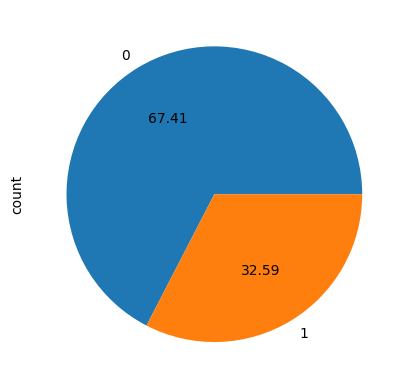

In [238]:
y.value_counts().plot.pie(autopct='%.2f')

## Spliting data into train and test

In [239]:
#the function train_test_split returns 4 diff values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=67)
# if you ever want to repeat the same split, you have to repeat random_state num

# always change this value when you change it in the function so that you can log it later
test_size=0.25


## Scale the data - normalize 

In [240]:
#create a scaler object so that we can normalize the data
scaler = StandardScaler()

# fit the scaler to the data and then transform the data
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)


# Logistic Regression

## Train the model

In [241]:
logistic_model = LogisticRegression(
    class_weight={0: 1, 1: 2},
    max_iter=500
)
# missing pcos patients is worse than misclassifying a non PCOS-patient
# so the clas 1 weights twice more than class 0

#actually train the model
logistic_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*","{0: 1, 1: 2}"
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For 

In [242]:
y_probs = logistic_model.predict_proba(X_test)[:, 1]


In [275]:
threshold = 0.63
y_predictions = (y_probs >= threshold).astype(int)

## Evaluation

In [276]:

print(classification_report(y_test, y_predictions))

              precision    recall  f1-score   support

           0       0.90      0.88      0.89        97
           1       0.71      0.76      0.73        38

    accuracy                           0.84       135
   macro avg       0.81      0.82      0.81       135
weighted avg       0.85      0.84      0.85       135



In [277]:
accuracy = accuracy_score(y_test, y_predictions)

print(f"Accuracy: {accuracy: .4f}")

Accuracy:  0.8444


In [278]:
confusion_matrix(y_test, y_predictions)

array([[85, 12],
       [ 9, 29]])

## Logs how each split and feature list perfomed


had help of ai with this specific loggins system becasue i am still learning py syntax

In [280]:
import os
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

# --- Path ---
log_path = r'logs\experiment_log.csv'
os.makedirs(os.path.dirname(log_path), exist_ok=True)

# --- Standard feature sets ---
feature_sets = {
    "hormone_features": hormone_features,
    "patient_observable_features": patient_observable_features,
    "doctor_observable_features": doctor_observable_features,
    "all_features": all_features
}

# --- Auto-detect feature set label ---
def get_feature_set_label(features, feature_sets):
    for label, columns in feature_sets.items():
        if set(features) == set(columns):
            return label
    return "custom_features"

# --- Load or initialize log ---
columns = [
    "Model", "Feature_Set", "Test_Size", "Class_Weight", "Threshold",
    "Accuracy", "Precision", "Recall", "TN", "FP", "FN", "TP"
]

try:
    experiment_log = pd.read_csv(log_path)
except (pd.errors.EmptyDataError, FileNotFoundError):
    experiment_log = pd.DataFrame(columns=columns)

# --- Grab info automatically from code ---
model_name = type(logistic_model).__name__
feature_set_label = get_feature_set_label(pcos_features, feature_sets)
class_weight = getattr(logistic_model, "class_weight", None)

# Predict and compute metrics
y_probs = logistic_model.predict_proba(X_test)[:, 1]
y_pred = (y_probs >= threshold).astype(int)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# --- Create log entry ---
new_entry = pd.DataFrame([{
    "Model": model_name,
    "Feature_Set": feature_set_label,
    "Test_Size": test_size,
    "Class_Weight": class_weight,
    "Threshold": threshold,
    "Accuracy": round(accuracy, 4),
    "Precision": round(precision, 4),
    "Recall": round(recall, 4),
    "TN": tn,
    "FP": fp,
    "FN": fn,
    "TP": tp
}])

# --- Append and save ---
experiment_log = pd.concat([experiment_log, new_entry], ignore_index=True)
experiment_log.to_csv(log_path, index=False)

print(f"Experiment logged successfully! Feature set: {feature_set_label}")


Experiment logged successfully! Feature set: patient_observable_features
